# W4 Development: SARSA vs Q-Learning on CliffWalking

Craig Rudman | MSDS684 | TDD development notebook  
All implementation lives in `../src/`. Tests live in `../tests/`.  
Work through TODOs in sequence; flip each to DONE when complete.

In [1]:
!python -m pytest ../tests/ --tb=no -q 2>&1 | tail -1

55 passed in 0.89s


In [2]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


---
## Phase 1: Infrastructure

In [3]:
# DONE: Create stub modules in src/
#   schedules.py     -- EpsilonSchedule (base), ConstantSchedule, LinearDecaySchedule, ExponentialDecaySchedule
#   agents.py        -- TDAgent (base), SARSAAgent, QLearningAgent
#   environment.py   -- EnvironmentManager
#   runner.py        -- EpisodeRunner
#   experiment.py    -- ExperimentConfig, ExperimentResult (with save()), ExperimentSuite (with summarize(output_path=None))
#   visualization.py -- Visualizer: plot_learning_curves, plot_policy_arrows, plot_value_heatmap, plot_trajectory
#                       each method accepts output_dir=None; saves figure to disk when provided, shows inline otherwise
#   main.py          -- CLI entry point: argparse, constructs ExperimentConfigs, runs suite, saves all outputs
#   __init__.py added to src/ and tests/



In [4]:
!tree ../src -P "*.py" --prune

../src
├── __init__.py
├── agents.py
├── environment.py
├── experiment.py
├── main.py
├── runner.py
├── schedules.py
└── visualization.py

1 directory, 8 files


In [5]:
# DONE: Create tests/conftest.py with shared fixtures
#   Fixtures: constant_schedule, linear_schedule, exp_schedule,
#             sarsa_agent, qlearning_agent, env_manager

# DONE: Create one test file per module in tests/
#   test_schedules.py, test_agents.py, test_environment.py,
#   test_runner.py, test_experiment.py, test_visualization.py

!tree ../tests -P "*.py" --prune

../tests
├── __init__.py
├── conftest.py
├── test_agents.py
├── test_environment.py
├── test_experiment.py
├── test_runner.py
├── test_schedules.py
└── test_visualization.py

1 directory, 8 files


In [6]:
# DONE: Sanity check CliffWalking-v0 before writing any implementation
#   Confirm: gymnasium installs cleanly, env.observation_space.n == 48, env.action_space.n == 4
#   Confirm: env.reset() returns integer state 36 (bottom-left start position)
#   Confirm: env.step() signature returns (int, float, bool, bool, dict)
#   Confirm: normal step reward == -1.0, cliff step reward == -100.0

In [7]:
import gymnasium as gym
# env = gym.make('CliffWalking-v0', is_slippery=False, )
# ENVIRONMENT = 'CliffWalking-v0'

# CliffWalking-v0 is depricated; using v1 instead
ENVIRONMENT = 'CliffWalking-v1'

env = gym.make(ENVIRONMENT)
print(env.observation_space)
print(env.action_space)
env.close()
print( gym.spec(ENVIRONMENT))

Discrete(48)
Discrete(4)
EnvSpec(id='CliffWalking-v1', entry_point='gymnasium.envs.toy_text.cliffwalking:CliffWalkingEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CliffWalking', version=1, additional_wrappers=(), vector_entry_point=None)


---
## Phase 2: ConstantSchedule (unblock agents)

In [8]:
# DONE: Implement ConstantSchedule
#   value property always returns epsilon; step() and reset() are no-ops
#   Tests: value is constant across multiple step() calls; reset() preserves value

---
## Phase 3: Agents, Environment, Runner (vertical slice)

In [9]:
# DONE: Implement TDAgent base class
#   Q-table initialized to zeros, shape (n_states, n_actions), dtype float
#   Tests: Q-table shape correct, dtype is float

# DONE: Implement TDAgent.select_action (epsilon-greedy)
#   Greedy: np.argmax(Q[state]); Explore: np.random.choice(n_actions)
#   Lab requires np.argmax() for greedy and np.random.choice() for exploration -- use these explicitly
#   Tests: always returns valid action in [0, n_actions); explores when epsilon=1.0; greedy when epsilon=0.0

# DONE: Implement TDAgent.reset_qtable
#   Zeros out Q-table in place
#   Tests: Q-table is all zeros after reset regardless of prior updates

# DONE: Implement TDAgent.decay_epsilon
#   Delegates to schedule.step()
#   Tests: agent epsilon reflects schedule value after decay call

# DONE: Implement SARSAAgent.update(s, a, r, s_next, a_next, terminated)
#   TD target: r + gamma * Q[s_next, a_next] (0 if terminated)
#   Q[s, a] += alpha * (target - Q[s, a])
#   Tests: Q-value moves toward target; terminal state produces zero bootstrap

# DONE: Implement QLearningAgent.update(s, a, r, s_next, a_next, terminated)
#   TD target: r + gamma * np.max(Q[s_next]) (0 if terminated); a_next is ignored
#   Lab requires np.max() for the Q-learning target -- use explicitly
#   Tests: Q-value moves toward target; uses np.max not a_next; terminal state produces zero bootstrap

# DONE: Implement EnvironmentManager
#   Wraps CliffWalking-v1; exposes n_states, n_actions
#   Tests: n_states == 48, n_actions == 4

# DONE: Implement EnvironmentManager.reset and EnvironmentManager.step
#   reset: accepts optional seed; returns integer state 36
#   step: returns (state, reward, terminated, truncated)
#   Tests: normal reward == -1.0; terminated and truncated are bool

# DONE: Implement EpisodeRunner.run_episode
#   Full SARSA-compatible loop: select a, step, select a', update, decay epsilon at end
#   Both agents use same loop; Q-learning ignores a_next internally
#   Tests: returns scalar total reward; reward <= -1 for any valid episode

# DONE: Implement EpisodeRunner.run_experiment
#   Outer loop over n_seeds: reset schedule, reset Q-table, reseed env, run n_episodes
#   Returns reward matrix of shape (n_seeds, n_episodes)
#   Tests: output shape is correct; all rewards are negative

In [10]:
# Demo 1: Agent initialization -- Q-table shape, dtype, and zero initialization
import sys
sys.path.insert(0, '../src')
import numpy as np
from schedules import ConstantSchedule
from agents import SARSAAgent

schedule = ConstantSchedule(epsilon=0.1)
agent = SARSAAgent(n_states=48, n_actions=4, alpha=0.1, gamma=1.0, schedule=schedule)

print(f"Q-table shape : {agent.Q.shape}")
print(f"Q-table dtype : {agent.Q.dtype}")
print(f"All zeros     : {np.all(agent.Q == 0.0)}")

Q-table shape : (48, 4)
Q-table dtype : float64
All zeros     : True


In [11]:
# Demo 2: Explore vs exploit -- action distribution at epsilon=1.0 vs epsilon=0.0
from agents import SARSAAgent
from schedules import ConstantSchedule
import numpy as np

# Explore: epsilon=1.0 should produce all four actions
explore_agent = SARSAAgent(48, 4, alpha=0.1, gamma=1.0, schedule=ConstantSchedule(1.0))
explore_actions = [explore_agent.select_action(0) for _ in range(200)]

# Exploit: epsilon=0.0 should always pick action 2 (highest Q-value)
exploit_agent = SARSAAgent(48, 4, alpha=0.1, gamma=1.0, schedule=ConstantSchedule(0.0))
exploit_agent.Q[0, 2] = 5.0
exploit_actions = [exploit_agent.select_action(0) for _ in range(200)]

print(f"Explore (epsilon=1.0) unique actions : {sorted(set(explore_actions))}")
print(f"Exploit (epsilon=0.0) unique actions : {sorted(set(exploit_actions))}")

Explore (epsilon=1.0) unique actions : [0, 1, 2, 3]
Exploit (epsilon=0.0) unique actions : [np.int64(2)]


In [12]:
# Demo 3: Single update comparison -- SARSA uses a_next, Q-learning uses max
import pandas as pd
from agents import SARSAAgent, QLearningAgent
from schedules import ConstantSchedule

def make_agent(cls):
    agent = cls(48, 4, alpha=0.1, gamma=1.0, schedule=ConstantSchedule(0.0))
    # Q[s_next] has a high value at action 2, but a_next=0 has value 0
    agent.Q[1, :] = [0.0, 0.0, 10.0, 0.0]
    return agent

sarsa = make_agent(SARSAAgent)
qlearn = make_agent(QLearningAgent)

# Both start with Q[0,0] = 0; update with r=-1, s_next=1, a_next=0
sarsa.update(s=0, a=0, r=-1.0, s_next=1, a_next=0, terminated=False)
qlearn.update(s=0, a=0, r=-1.0, s_next=1, a_next=0, terminated=False)

# SARSA uses Q[1,0]=0.0 -> target = -1 + 0 = -1 -> Q[0,0] moves to -0.1
# Q-learning uses max(Q[1])=10.0 -> target = -1 + 10 = 9 -> Q[0,0] moves to 0.9
pd.DataFrame({
    'Q[0,0] after update': [sarsa.Q[0, 0], qlearn.Q[0, 0]],
    'bootstrap source':    ['Q[s_next, a_next]=0.0', 'max(Q[s_next])=10.0'],
}, index=['SARSAAgent', 'QLearningAgent'])

,"Q[0,0] after update",bootstrap source
SARSAAgent,-0.1,"Q[s_next, a_next]=0.0"
QLearningAgent,0.9,max(Q[s_next])=10.0


In [13]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
from schedules import ConstantSchedule
from agents import SARSAAgent, QLearningAgent
from environment import EnvironmentManager
from runner import EpisodeRunner

env = EnvironmentManager()
schedule = ConstantSchedule(epsilon=0.1)
agent = SARSAAgent(n_states=env.n_states, n_actions=env.n_actions, alpha=0.1, gamma=1.0, schedule=schedule)
runner = EpisodeRunner(agent, env)

matrix = runner.run_experiment(n_seeds=5, n_episodes=50)

# Show mean reward across seeds for first, middle, and last 10 episodes
df = pd.DataFrame({
    'first_10':  matrix[:, :10].mean(axis=1),
    'middle_10': matrix[:, 20:30].mean(axis=1),
    'last_10':   matrix[:, -10:].mean(axis=1),
})
print(df.describe().round(1))

       first_10  middle_10  last_10
count       5.0        5.0      5.0
mean     -540.3     -131.3    -89.2
std        69.2       27.1     26.1
min      -659.7     -159.0   -126.9
25%      -540.3     -146.5   -105.6
50%      -508.5     -135.6    -77.2
75%      -499.6     -127.5    -68.2
max      -493.2      -87.7    -68.0


---
## Phase 4: Decay Schedules

In [14]:
# DONE: Implement LinearDecaySchedule
#   value decays linearly from epsilon_start to epsilon_end over n_episodes steps
#   reset() restores episode counter to 0
#   Tests: value at step 0, value at step n_episodes, does not go below epsilon_end, reset restores initial value

# DONE: Implement ExponentialDecaySchedule
#   value = epsilon_start * (decay_rate ** episode)
#   reset() restores episode counter to 0
#   Tests: decreases monotonically, never reaches zero, reset restores initial value

In [15]:
# Demo 1: Decay profiles -- epsilon value at key checkpoints over 500 episodes
import sys
sys.path.insert(0, '../src')
import pandas as pd
from schedules import LinearDecaySchedule, ExponentialDecaySchedule

N = 500
linear = LinearDecaySchedule(epsilon_start=1.0, epsilon_end=0.01, n_episodes=N)
exp    = ExponentialDecaySchedule(epsilon_start=1.0, decay_rate=0.995)

checkpoints = [0, N//4, N//2, 3*N//4, N]
rows = []
for ep in checkpoints:
    linear.reset(); exp.reset()
    for _ in range(ep):
        linear.step(); exp.step()
    rows.append({'episode': ep, 'LinearDecay': round(linear.value, 4), 'ExponentialDecay': round(exp.value, 4)})

pd.DataFrame(rows).set_index('episode')

,LinearDecay,ExponentialDecay
episode,,
0,1.0000,1.0000
125,0.7525,0.5344
250,0.5050,0.2856
375,0.2575,0.1526
500,0.0100,0.0816


In [16]:
# Demo 2: Reset behavior -- confirm value returns to epsilon_start after reset
from schedules import LinearDecaySchedule, ExponentialDecaySchedule

linear = LinearDecaySchedule(epsilon_start=1.0, epsilon_end=0.01, n_episodes=500)
exp    = ExponentialDecaySchedule(epsilon_start=1.0, decay_rate=0.995)

# Run both to completion
for _ in range(500):
    linear.step(); exp.step()

print(f"LinearDecay    after 500 steps : {linear.value:.4f}")
print(f"ExponentialDecay after 500 steps : {exp.value:.4f}")

linear.reset(); exp.reset()

print(f"\nLinearDecay    after reset : {linear.value:.4f}")
print(f"ExponentialDecay after reset : {exp.value:.4f}")

LinearDecay    after 500 steps : 0.0100
ExponentialDecay after 500 steps : 0.0816

LinearDecay    after reset : 1.0000
ExponentialDecay after reset : 1.0000


---
## Phase 5: Experiment Framework

In [17]:
# DONE: Implement ExperimentConfig dataclass
#   Fields: label, agent_class, alpha, epsilon_schedule, n_seeds, n_episodes
#   Tests: instantiates cleanly; fields are accessible

# DONE: Implement ExperimentResult
#   Holds config reference and reward matrix
#   Defines metric methods: final_performance, learning_speed, sample_efficiency
#   Revisit metric definitions before implementing (deferred from design discussion)
#   save(output_dir): writes reward matrix as .npy file named by config.label
#   Tests: metrics return scalar values; final_performance <= -1; save() writes a file to disk

# DONE: Implement ExperimentSuite
#   Accepts list of ExperimentConfig; runs each via EpisodeRunner
#   summarize(output_path=None): returns DataFrame; writes CSV when output_path is provided
#   Tests: DataFrame has expected columns; one row per config; CSV written when output_path given

In [18]:
# Demo 1: ExperimentConfig -- confirm fields are accessible
import sys
sys.path.insert(0, '../src')
from experiment import ExperimentConfig
from agents import SARSAAgent
from schedules import ConstantSchedule

config = ExperimentConfig(
    label='sarsa_baseline',
    agent_class=SARSAAgent,
    alpha=0.1,
    epsilon_schedule=ConstantSchedule(0.1),
    n_seeds=5,
    n_episodes=100,
)

print(f"label            : {config.label}")
print(f"agent_class      : {config.agent_class.__name__}")
print(f"alpha            : {config.alpha}")
print(f"n_seeds          : {config.n_seeds}")
print(f"n_episodes       : {config.n_episodes}")

label            : sarsa_baseline
agent_class      : SARSAAgent
alpha            : 0.1
n_seeds          : 5
n_episodes       : 100


In [19]:
# Demo 2: ExperimentResult metrics -- run a short experiment and inspect all three metrics
import numpy as np
from experiment import ExperimentConfig, ExperimentResult
from agents import SARSAAgent
from schedules import ConstantSchedule
from environment import EnvironmentManager
from runner import EpisodeRunner

env = EnvironmentManager()
config = ExperimentConfig(
    label='sarsa_demo',
    agent_class=SARSAAgent,
    alpha=0.1,
    epsilon_schedule=ConstantSchedule(0.1),
    n_seeds=10,
    n_episodes=200,
)
agent = SARSAAgent(env.n_states, env.n_actions, alpha=config.alpha, gamma=1.0, schedule=config.epsilon_schedule)
matrix = EpisodeRunner(agent, env).run_experiment(config.n_seeds, config.n_episodes)
result = ExperimentResult(config, matrix)

print(f"final_performance  : {result.final_performance():.1f}  (mean reward over last 10% of episodes)")
print(f"learning_speed     : {result.learning_speed()}          (episode where 90% of improvement achieved)")
print(f"sample_efficiency  : {result.sample_efficiency():.1f}  (mean reward across all episodes -- normalized AUC)")

final_performance  : -34.7  (mean reward over last 10% of episodes)
learning_speed     : 122          (episode where 90% of improvement achieved)
sample_efficiency  : -91.8  (mean reward across all episodes -- normalized AUC)


In [20]:
# Demo 3: ExperimentSuite -- run SARSA vs Q-learning and show comparison table
from experiment import ExperimentConfig, ExperimentSuite
from agents import SARSAAgent, QLearningAgent
from schedules import ConstantSchedule
from environment import EnvironmentManager

env = EnvironmentManager()
configs = [
    ExperimentConfig('sarsa',    SARSAAgent,     alpha=0.1, epsilon_schedule=ConstantSchedule(0.1), n_seeds=5, n_episodes=50),
    ExperimentConfig('qlearning', QLearningAgent, alpha=0.1, epsilon_schedule=ConstantSchedule(0.1), n_seeds=5, n_episodes=50),
]
suite = ExperimentSuite(configs, env)
suite.run()
suite.summarize().round(1)

,label,final_performance,learning_speed,sample_efficiency
0,sarsa,-87.3,20,-206.1
1,qlearning,-114.1,18,-215.4


---
## Phase 6: Baseline Experiments

In [21]:
import os
OUTPUT_DIR = '../results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")

Output directory: /Users/crudman/Documents/GitHub/MSDS684/W4/results


In [22]:
# DONE: Run baseline experiment
#   SARSA vs Q-learning, default params: alpha=0.1, epsilon=0.1 (constant), 30 seeds, 500 episodes
#   Confirm reward matrices are shaped (30, 500) and values are in expected range


In [23]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

from experiment import ExperimentConfig, ExperimentSuite
from agents import SARSAAgent, QLearningAgent
from schedules import ConstantSchedule
from environment import EnvironmentManager

env = EnvironmentManager()
configs = [
    ExperimentConfig('SARSA',      SARSAAgent,     alpha=0.1, epsilon_schedule=ConstantSchedule(0.1), n_seeds=30, n_episodes=500),
    ExperimentConfig('Q-Learning', QLearningAgent, alpha=0.1, epsilon_schedule=ConstantSchedule(0.1), n_seeds=30, n_episodes=500),
]
suite = ExperimentSuite(configs, env)
results = suite.run()

for r in results:
    print(f"{r.config.label}: shape={r.reward_matrix.shape}, min={r.reward_matrix.min():.0f}, max={r.reward_matrix.max():.0f}")


SARSA: shape=(30, 500), min=-3455, max=-15
Q-Learning: shape=(30, 500), min=-3537, max=-13


In [24]:
# DONE: Plot learning curves with 95% CI
#   Y-axis: mean episode return (sum of rewards within episode) across seeds -- not per-step reward
#   CI bands: mean +/- 1.96 * np.std(matrix, axis=0) / np.sqrt(n_seeds)  -- NumPy only, no scipy
#   Both algorithms on same axes for direct comparison
#   Expected: Q-learning shows lower mean episode return during training (more cliff falls due to exploration)

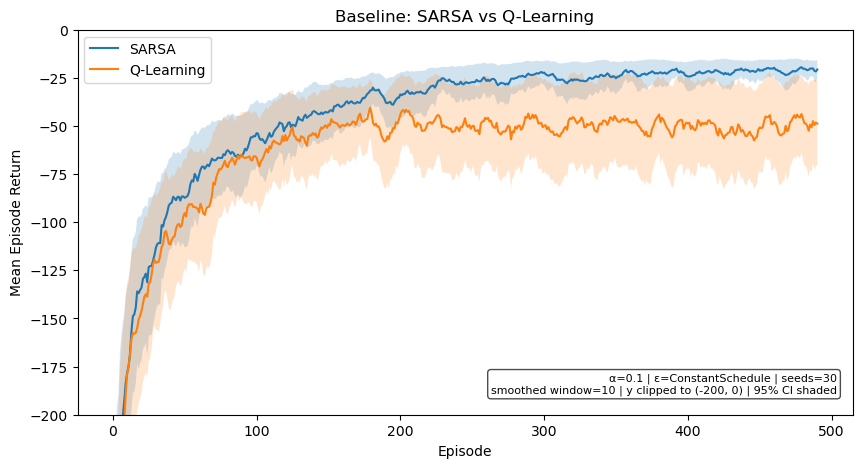

In [25]:
from visualization import Visualizer

Visualizer(env).plot_learning_curves(results, ylim=(-200, 0), smooth_window=10,
    output_dir=OUTPUT_DIR, filename="baseline_learning_curves",
    title="Baseline: SARSA vs Q-Learning")

---
## Phase 7: Baseline Visualizations

In [26]:
# DONE: Visualize learned policy as arrows on the grid
#   Greedy action at each state shown as directional arrow
#   Side-by-side: SARSA policy (safe upper path) vs Q-learning policy (cliff-hugging)

# DONE: Visualize value function heatmaps
#   max Q-value per state shown as color intensity
#   Side-by-side: SARSA vs Q-learning value surfaces

# DONE: Plot sample trajectories
#   Roll out greedy policy from trained agent (epsilon=0)
#   Show path on grid overlay for SARSA and Q-learning

# DONE: Document behavioral differences
#   Explain safe path vs cliff-hugging path in terms of on-policy vs off-policy TD targets
#   Connect to Sutton & Barto Ch. 6 discussion of SARSA vs Q-learning on CliffWalking

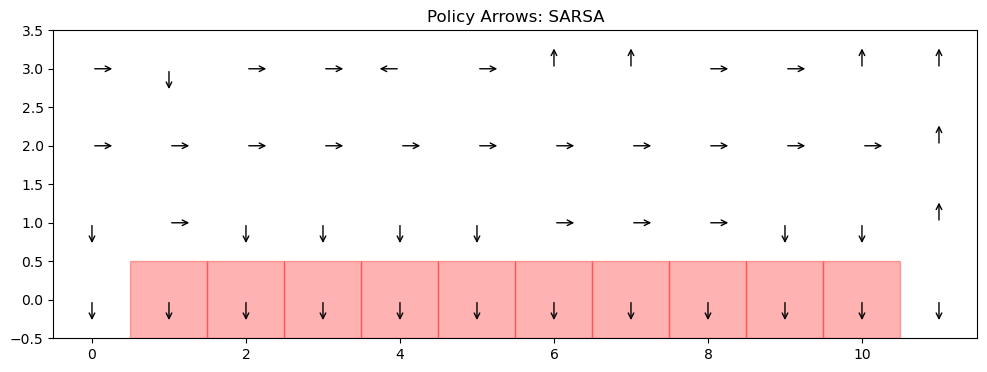

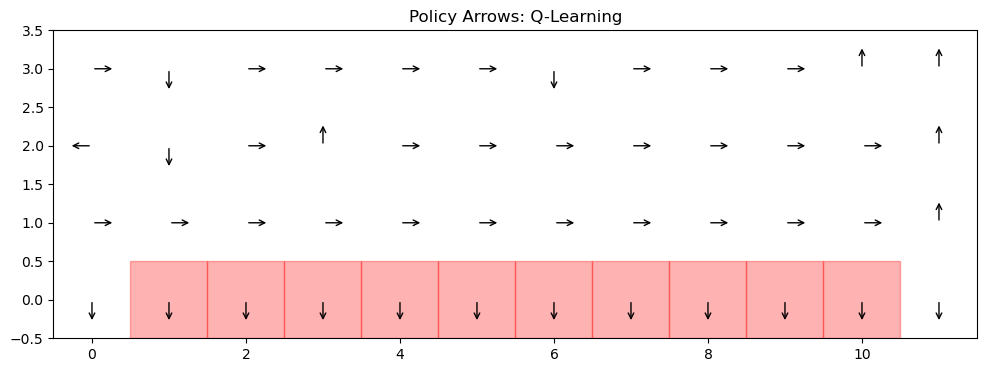

In [27]:
# Phase 7: Policy arrows -- greedy action at each state for SARSA and Q-learning
from visualization import Visualizer

vis = Visualizer(env)
for r in results:
    vis.plot_policy_arrows(r.q_table, label=r.config.label, output_dir=OUTPUT_DIR)

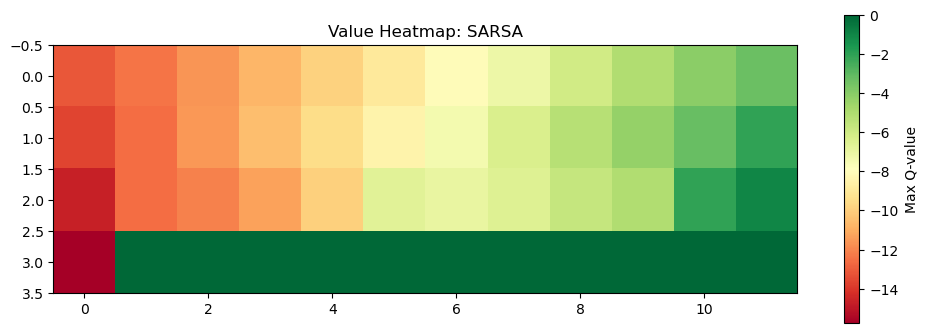

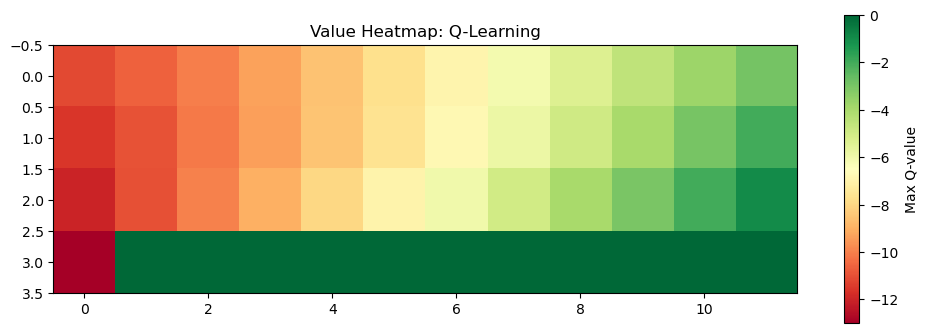

In [28]:
# Phase 7: Value heatmaps -- max Q-value per state for SARSA and Q-learning
for r in results:
    vis.plot_value_heatmap(r.q_table, label=r.config.label, output_dir=OUTPUT_DIR)

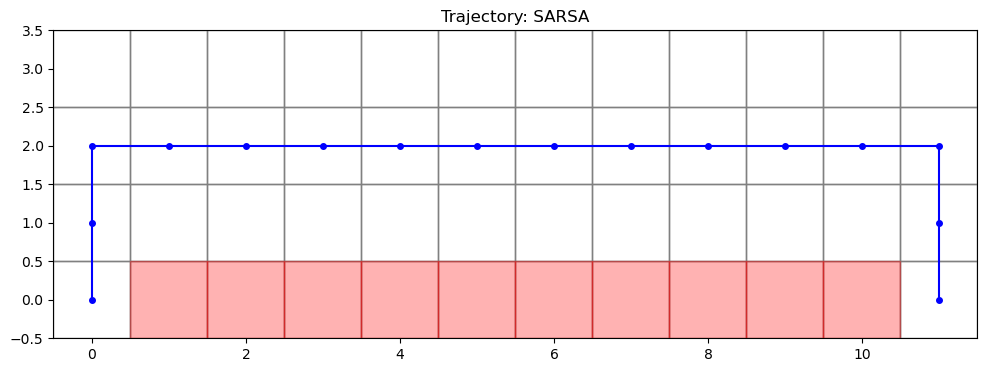

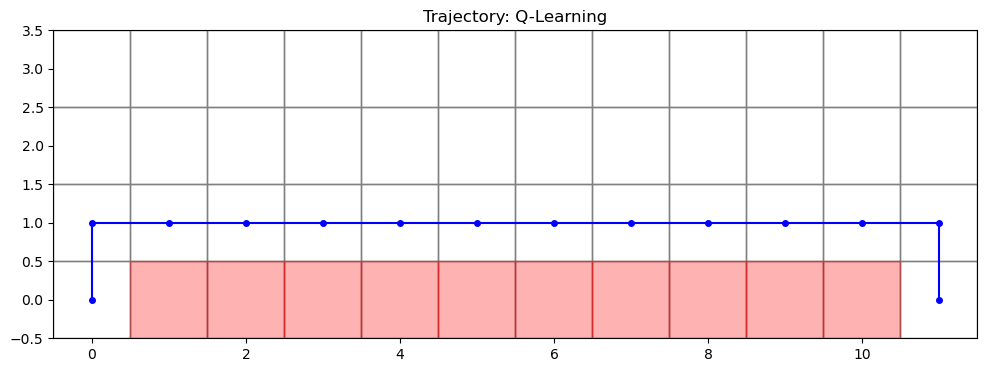

In [29]:
# Phase 7: Trajectories -- greedy rollout from start state for SARSA and Q-learning
for r in results:
    vis.plot_trajectory(r.q_table, label=r.config.label, output_dir=OUTPUT_DIR)

---
## Phase 8: Hyperparameter Experiments

In [40]:
PERFORMANCE_WEIGHTS={
    'final_performance': 0.5,
    'learning_speed':    0.1,
    'sample_efficiency': 0.4,
}

In [41]:
# DONE: Experiment with step-size alpha
#   Compare alpha in [0.05, 0.1, 0.3, 0.5] for both agents
#   Observe effect on learning speed and stability

# DONE: Experiment with epsilon schedules
#   Compare: ConstantSchedule(0.1), LinearDecaySchedule, ExponentialDecaySchedule
#   Observe: does decay cause Q-learning to eventually prefer the cliff-hugging path more reliably?
#   Observe: does decay cause SARSA to shift from safe path toward optimal path as epsilon shrinks?

In [42]:
# Phase 8: Alpha sweep -- compare alpha in [0.05, 0.1, 0.3, 0.5] for both agents
from experiment import ExperimentConfig, ExperimentSuite
from agents import SARSAAgent, QLearningAgent
from schedules import ConstantSchedule
from environment import EnvironmentManager
from visualization import Visualizer
import matplotlib.pyplot as plt
import numpy as np

env = EnvironmentManager()
alphas = [0.05, 0.1, 0.3, 0.5]

alpha_configs = []
for alpha in alphas:
    alpha_configs.append(ExperimentConfig(
        label=f'SARSA α={alpha}',
        agent_class=SARSAAgent,
        alpha=alpha,
        epsilon_schedule=ConstantSchedule(0.1),
        n_seeds=30, n_episodes=500,
    ))
    alpha_configs.append(ExperimentConfig(
        label=f'Q-Learning α={alpha}',
        agent_class=QLearningAgent,
        alpha=alpha,
        epsilon_schedule=ConstantSchedule(0.1),
        n_seeds=30, n_episodes=500,
    ))

alpha_suite = ExperimentSuite(alpha_configs, env)
alpha_results = alpha_suite.run()
print("Alpha sweep complete.")

Alpha sweep complete.


In [43]:
print("Alpha sweep, sorted by performance_index...")
alpha_suite.summarize(
    output_path=os.path.join(OUTPUT_DIR, 'alpha_sweep_summary.csv'),
    weights=PERFORMANCE_WEIGHTS,
    sort_by='performance_index',
    ascending = False
).round(3)

Alpha sweep, sorted by performance_index...


,label,final_performance,learning_speed,sample_efficiency,performance_index
0,SARSA α=0.3,-23.613,37,-36.737,0.950
1,SARSA α=0.5,-28.293,15,-37.622,0.887
2,SARSA α=0.1,-22.351,65,-51.676,0.825
3,SARSA α=0.05,-26.977,105,-75.541,0.520
4,Q-Learning α=0.5,-47.532,11,-56.062,0.424
5,Q-Learning α=0.3,-50.460,9,-59.030,0.353
6,Q-Learning α=0.1,-52.067,38,-70.251,0.209
7,Q-Learning α=0.05,-47.833,104,-88.090,0.072


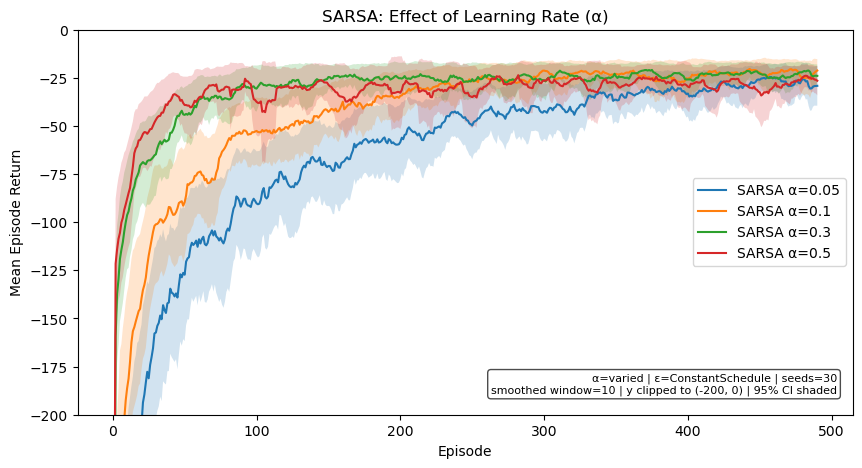

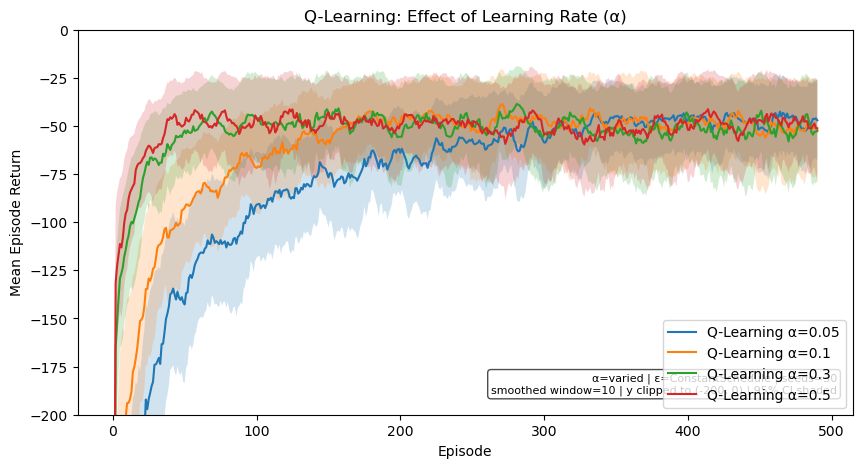

In [44]:
# Phase 8: Alpha sweep -- one plot per agent, all alpha values overlaid
vis = Visualizer(env)
for agent_label in ["SARSA", "Q-Learning"]:
    subset = [r for r in alpha_results if r.config.label.startswith(agent_label)]
    vis.plot_learning_curves(subset, ylim=(-200, 0), smooth_window=10,
        output_dir=OUTPUT_DIR, filename=f"{agent_label}_alpha_sweep",
        title=f"{agent_label}: Effect of Learning Rate (α)")

In [45]:
# Phase 8: Schedule sweep -- compare ConstantSchedule, LinearDecaySchedule, ExponentialDecaySchedule
from schedules import LinearDecaySchedule, ExponentialDecaySchedule

schedules = {
    'Constant(0.1)':    ConstantSchedule(0.1),
    'LinearDecay':      LinearDecaySchedule(epsilon_start=1.0, epsilon_end=0.01, n_episodes=500),
    'ExponentialDecay': ExponentialDecaySchedule(epsilon_start=1.0, decay_rate=0.995),
}

schedule_configs = []
for sched_label, sched in schedules.items():
    schedule_configs.append(ExperimentConfig(
        label=f'SARSA {sched_label}',
        agent_class=SARSAAgent,
        alpha=0.1,
        epsilon_schedule=sched,
        n_seeds=30, n_episodes=500,
    ))
    schedule_configs.append(ExperimentConfig(
        label=f'Q-Learning {sched_label}',
        agent_class=QLearningAgent,
        alpha=0.1,
        epsilon_schedule=sched,
        n_seeds=30, n_episodes=500,
    ))

schedule_suite = ExperimentSuite(schedule_configs, env)
schedule_results = schedule_suite.run()
print("Schedule sweep complete.")

Schedule sweep complete.


In [46]:
schedule_suite.summarize(
    output_path=os.path.join(OUTPUT_DIR, 'schedule_sweep_summary.csv'),
    weights=PERFORMANCE_WEIGHTS,
    sort_by='performance_index',
    ascending = False
).round(3)

,label,final_performance,learning_speed,sample_efficiency,performance_index
0,SARSA Constant(0.1),-23.387,52,-51.849,0.862
1,SARSA ExponentialDecay,-22.859,17,-1126.626,0.838
2,SARSA LinearDecay,-19.999,38,-2705.216,0.666
3,Q-Learning Constant(0.1),-50.829,43,-71.368,0.436
4,Q-Learning ExponentialDecay,-46.493,18,-1788.671,0.382
5,Q-Learning LinearDecay,-33.415,59,-3783.823,0.282


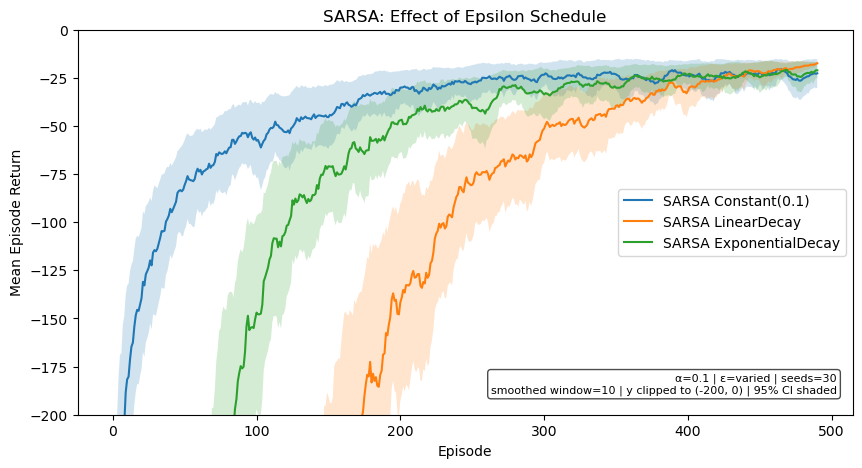

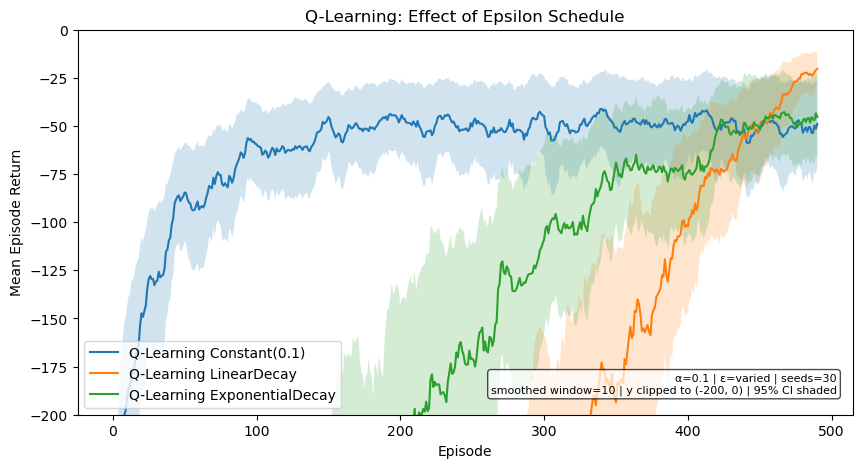

In [47]:
# Phase 8: Schedule sweep -- one plot per agent, all schedule types overlaid
for agent_label in ["SARSA", "Q-Learning"]:
    subset = [r for r in schedule_results if r.config.label.startswith(agent_label)]
    vis.plot_learning_curves(subset, ylim=(-200, 0), smooth_window=10,
        output_dir=OUTPUT_DIR, filename=f"{agent_label}_schedule_sweep",
        title=f"{agent_label}: Effect of Epsilon Schedule")

---
## Phase 9: Comparison Table and Final Analysis

In [48]:
# TODO: Generate comparison table via ExperimentSuite.summarize()
#   Columns: algorithm, alpha, epsilon_schedule, final_performance, learning_speed, sample_efficiency
#   Include all experimental configurations from Phases 7 and 9

# TODO: Write final analysis
#   Synthesize: which algorithm is better and under what conditions?
#   Address: training performance vs greedy (test-time) performance distinction
#   Address: how hyperparameters shift the safe/risky path trade-off
#   Cite: Sutton & Barto sections as appropriate

---
## Phase 10: CLI Entry Point

In [49]:
# TODO: Implement main.py
#   argparse arguments: --n-seeds (default 30), --n-episodes (default 500), --output-dir (default ./results)
#   Constructs all ExperimentConfigs (baseline + alpha sweep + schedule sweep)
#   Runs ExperimentSuite, calls result.save(output_dir) for each result
#   Calls Visualizer methods with output_dir to save all figures to disk
#   Calls suite.summarize(output_path) to write comparison table as CSV
#   Prints progress to stdout so long runs are observable

# TODO: Verify CLI invocation end-to-end
#   Run: python ../src/main.py --n-seeds 2 --n-episodes 10 --output-dir /tmp/test_run
#   Confirm: results directory populated with .npy files, plots, and summary.csv
#   Confirm: full production run works: python ../src/main.py --output-dir ./results